In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb
import emcee
from pathlib import Path
from scipy.special import eval_legendre
from scipy.interpolate import CubicSpline

import sys
sys.path.insert(0, '/home/cosweeney/code/EmulateLSS')
from train_nn_emu import train_emu 
from emulator import Emulator

# ------------------------------------------------------------------
# Fixed setup
# ------------------------------------------------------------------
Z_FIT = 0.5
NS_FIXED = 0.9649                       # matches GetLPTInputs / fixed to Planck '19
COSMO_FID = [0.6777, 0.02214, 0.11891, 2.2e-9]  # h, ombh2, omch2, As -- same as GetLPTInputs.cosmo_fid

# theory grid the emulators were trained/predict on
S_MODEL = np.arange(16.0, 168.0 + 4.0, 1.0)      # 16-168 h^-1 Mpc, 1 h^-1 Mpc spacing

output_path = '/spiffball/cosweeney/data/models/'
emu_xi0 = Emulator(output_path + 'compact_xi0_z0p5')
emu_xi2 = Emulator(output_path + 'compact_xi2_z0p5')
emu_xi4 = Emulator(output_path + 'compact_xi4_z0p5')

I0000 00:00:1788992645.190981 2094315 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788992645.194302 2094315 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788992645.319855 2094315 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788992647.833594 2094315 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [35]:
# ------------------------------------------------------------------
# AP: lightweight background-only version (no P(k), no transfer functions)
# ------------------------------------------------------------------
import os

# Set the desired number of threads
os.environ["OMP_NUM_THREADS"] = "4"

def get_background(h, ombh2, omch2):
    pars = camb.set_params(H0=100. * h, ombh2=ombh2, omch2=omch2)
    return camb.get_background(pars)   # background only -- fast, exact D_A(z)/H(z)

_results_fid = get_background(*COSMO_FID[:3])
H_FID = _results_fid.hubble_parameter(Z_FIT)
D_A_FID = _results_fid.angular_diameter_distance(Z_FIT)

def ap_params(h, ombh2, omch2):
    results = get_background(h, ombh2, omch2)
    H = results.hubble_parameter(Z_FIT)
    D_A = results.angular_diameter_distance(Z_FIT)
    q_perp = D_A / D_A_FID
    q_par = H_FID / H
    return q_perp, q_par

def apply_AP(s_fid, mu_fid, q_perp, q_par):
    q_a = q_par**(1/3) * q_perp**(2/3)
    q_e = (q_par / q_perp)**(1/3)
    s_p = s_fid * q_a * np.sqrt(q_e**4 * mu_fid**2 + (1 - mu_fid**2) / q_e**2)
    mu_p = 1 / np.sqrt(1 + (1 / mu_fid**2 - 1) / q_e**6)
    return s_p, mu_p


# ------------------------------------------------------------------
# AP mixing (eq. 5.7), done by Gauss-Legendre quadrature over mu_ref in [0,1]
# ------------------------------------------------------------------
N_MU = 40
_nodes, _wts = np.polynomial.legendre.leggauss(N_MU)
MU_REF = 0.5 * (_nodes + 1.0)   # remapped from [-1,1] to [0,1]
W_MU = 0.5 * _wts

def ap_multipoles(s_data, ells_out, xi0_model, xi2_model, xi4_model, q_perp, q_par):
    """AP-distorted multipoles `ells_out` at `s_data`, given model xi_0,2,4 on S_MODEL."""
    spline0 = CubicSpline(S_MODEL, xi0_model, extrapolate=False)
    spline2 = CubicSpline(S_MODEL, xi2_model, extrapolate=False)
    spline4 = CubicSpline(S_MODEL, xi4_model, extrapolate=False)

    out = np.empty((len(ells_out), len(s_data)))
    for j, s_ref in enumerate(s_data):
        s_p, mu_p = apply_AP(s_ref, MU_REF, q_perp, q_par)
        xi_smu = (spline0(s_p) * eval_legendre(0, mu_p)
                  + spline2(s_p) * eval_legendre(2, mu_p)
                  + spline4(s_p) * eval_legendre(4, mu_p))
        for i, ell in enumerate(ells_out):
            out[i, j] = (2 * ell + 1) * np.sum(W_MU * xi_smu * eval_legendre(ell, mu_p))
    return out


# ------------------------------------------------------------------
# Data: mean multipoles + covariance, matched to cov binning, s <= 130
# ------------------------------------------------------------------
NBINS_COV, NELLS_COV = 45, 3          # ell = 0, 2, 4, s in (20, 200) step 4 -- RascalC convention
S_COV = np.arange(22., 199., 4.)      # bin centers
SMAX_FIT = 130.
MOCK_IDX = 4 # which individual mock to use
ELLS_FIT = (0, 2)
REBIN = 4   # 1 h^-1 Mpc -> 4 h^-1 Mpc, to match covariance binning

def rebin_mean(arr, rebin, axis=-1):
    """Block-average `arr` along `axis` in groups of `rebin`. Trims any remainder bins."""
    n = arr.shape[axis]
    n_keep = (n // rebin) * rebin
    arr = np.take(arr, np.arange(n_keep), axis=axis)
    new_shape = arr.shape[:axis] + (n_keep // rebin, rebin) + arr.shape[axis + 1:] if axis != -1 else \
                arr.shape[:-1] + (n_keep // rebin, rebin)
    return arr.reshape(new_shape).mean(axis=-1)

def load_data(poles_path, cov_path, mock_idx=None):
    """poles_path: npz from the non-rebinned, srange=(20,200) export.
    Rebinned here (factor REBIN) to match the covariance binning.
    cov_path: RascalC covariance (single-mock), ell-blocks ordered 0, 2, 4.
    mock_idx: if given, use that single mock's multipoles as DATA_VEC;
              if None, use the mean over all mocks."""
    d = np.load(poles_path)
    s_fine, poles_fine = d['s'], d['poles']        # s: (180,), poles: (nmock, 3, 180)

    s = rebin_mean(s_fine, REBIN)                  # (45,)
    poles = rebin_mean(poles_fine, REBIN, axis=-1) # (nmock, 3, 45)
    target = poles[mock_idx] if mock_idx is not None else poles.mean(axis=0)  # (3, 45)

    cov_full = np.loadtxt(cov_path)

    mask = s <= SMAX_FIT
    ell_all = (0, 2, 4)
    idx = np.concatenate([
        ell_all.index(ell) * NBINS_COV + np.where(mask)[0] for ell in ELLS_FIT
    ])

    data_vec = np.concatenate([target[ell_all.index(ell)][mask] for ell in ELLS_FIT])
    cov = cov_full[np.ix_(idx, idx)]
    s_data = s[mask]
    return s_data, data_vec, cov #/ 24

S_DATA, DATA_VEC, COV = load_data(
    poles_path='/spiffball/cosweeney/mocks/AbacusSummit/dark/LRG_z0.4-0.6_poles.npz',   # TODO: path to the non-rebinned, srange=(20,200) export for LRG z0.4-0.6
    cov_path="/spiffball/cosweeney/mocks/AbacusSummit/covariances/dark/xi024_LRG_GCcomb_0.4_0.6_default_FKP_lin4_s20-200_cov_RascalC_rescaled_mocks.txt" ,
    mock_idx=None 
)
N_PER_ELL = len(S_DATA)

In [36]:
# ------------------------------------------------------------------
# Model
# ------------------------------------------------------------------
def model_multipoles(theta):
    h, ombh2, omch2, lnAs, b1, b2, _, _ = theta
    emu_params = [b1, b2, ombh2, omch2, h, lnAs]
    _, xi0 = emu_xi0(emu_params)
    _, xi2 = emu_xi2(emu_params)
    _, xi4 = emu_xi4(emu_params)

    q_perp, q_par = ap_params(h, ombh2, omch2)
    model = ap_multipoles(S_DATA, ELLS_FIT, xi0, xi2, xi4, q_perp, q_par)
    return model.ravel()   # [xi0(s_data), xi2(s_data)]


# ------------------------------------------------------------------
# Likelihood / prior
# ------------------------------------------------------------------
OMBH2_MEAN, OMBH2_SIG = 0.02237, 0.00037
D_MIN, D_MAX = 0.0, 100.0    # TODO: confirm -- placeholder range for scatter terms, linear scale

N_MOCKS_FIT = 1   # 1 for a single mock (COV as-is); use 25 when fitting the mean of all mocks

def log_prior(theta):
    h, ombh2, omch2, lnAs, b1, b2, d0, d2 = theta
    if not (0.55 < h < 0.91):        return -np.inf
    if not (0.08 < omch2 < 0.16):    return -np.inf
    if not (2.0 < lnAs < 4.0):       return -np.inf
    if not (0.0 < b1 < 2.0):         return -np.inf
    if not (-5.0 < b2 < 10.0):       return -np.inf
    if not (D_MIN < d0 < D_MAX):     return -np.inf
    if not (D_MIN < d2 < D_MAX):     return -np.inf
    return -0.5 * ((ombh2 - OMBH2_MEAN) / OMBH2_SIG) ** 2

def log_likelihood(theta):
    d0, d2 = theta[-2], theta[-1]
    extra_var = np.concatenate([
        np.full(N_PER_ELL, d0 ** 2),
        np.full(N_PER_ELL, d2 ** 2),
    ])
    cov_tot = COV / N_MOCKS_FIT + np.diag(extra_var)

    try:
        model = model_multipoles(theta)
    except Exception:
        return -np.inf
    if not np.all(np.isfinite(model)):
        return -np.inf

    resid = model - DATA_VEC
    sign, logdet = np.linalg.slogdet(2 * np.pi * cov_tot)
    if sign <= 0:
        return -np.inf
    chi2 = resid @ np.linalg.solve(cov_tot, resid)
    return -0.5 * (chi2 + logdet)

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

In [17]:
%%timeit

log_likelihood(pos[0])

149 ms ± 6.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [37]:
# ------------------------------------------------------------------
# Run
# ------------------------------------------------------------------
NDIM = 8
NWALKERS = 32
NSTEPS = 1500

lnAs_fid = np.log(1e10 * COSMO_FID[3])
theta0 = np.array([COSMO_FID[0], COSMO_FID[1], COSMO_FID[2], lnAs_fid, 1.0, 0.0, 5.0, 5.0])
scale  = np.array([0.01,   0.0001,  0.002,  0.02, 0.02, 0.1, 0.1,  0.1])
pos = theta0 + scale * np.random.randn(NWALKERS, NDIM)

sampler = emcee.EnsembleSampler(NWALKERS, NDIM, log_probability)
sampler.run_mcmc(pos, NSTEPS, progress=True)

100%|██████████| 1500/1500 [1:23:17<00:00,  3.33s/it]


State([[ 7.02350287e-01  2.24624673e-02  1.38296898e-01  2.92794812e+00
   7.39332949e-01 -1.24694950e+00  1.82976922e-04  3.84502260e-05]
 [ 6.64557465e-01  2.18630996e-02  1.15010073e-01  3.19040169e+00
   7.53394901e-01 -8.25271884e-01  1.54920685e-04  2.95217363e-04]
 [ 6.89376309e-01  2.21743986e-02  1.28059019e-01  2.70809818e+00
   1.10544710e+00 -2.26822322e-02  1.65076084e-04  1.94678117e-04]
 [ 6.81306117e-01  2.20224122e-02  1.19343604e-01  3.26497801e+00
   5.85402307e-01 -9.27598459e-01  8.95122405e-05  1.73827636e-04]
 [ 6.72327132e-01  2.20172759e-02  1.13580361e-01  2.69887864e+00
   1.36279896e+00  1.23511368e+00  7.20850916e-05  1.17736435e-04]
 [ 6.71098889e-01  2.25512561e-02  1.19561092e-01  2.87755044e+00
   1.04285367e+00 -8.40150374e-01  6.37110420e-05  9.23952870e-05]
 [ 6.89836688e-01  2.29576361e-02  1.37946372e-01  2.70396129e+00
   1.07841830e+00 -2.85206919e-01  1.77113276e-05  1.41932801e-04]
 [ 6.74012387e-01  2.22216894e-02  1.23230752e-01  2.96226720e+

In [56]:
# continuing 

NSTEPS = 500

pos_continue = sampler.get_last_sample().coords   # (nwalkers, ndim), last step of the previous run

sampler.run_mcmc(pos_continue, NSTEPS, progress=True)

100%|██████████| 500/500 [37:46<00:00,  4.53s/it]


State([[ 6.75595169e-01  2.25036201e-02  1.19974509e-01  3.13315462e+00
   7.50866001e-01 -8.57469291e-01  2.71047552e-06  1.13264980e-04]
 [ 6.73483657e-01  2.21975075e-02  1.20833288e-01  3.12057550e+00
   7.57665482e-01 -9.19182942e-01  3.61693662e-07  2.50640949e-05]
 [ 6.76608516e-01  2.28963872e-02  1.24009803e-01  3.08427167e+00
   7.64814555e-01 -1.06955760e+00  1.20380213e-05  1.97116446e-05]
 [ 6.75474063e-01  2.29801175e-02  1.18966582e-01  3.08615314e+00
   8.01028541e-01 -8.95491062e-01  3.68067883e-05  4.26447215e-05]
 [ 6.75373147e-01  2.27188847e-02  1.20570356e-01  3.08780953e+00
   7.91718919e-01 -9.07851182e-01  2.55814511e-05  5.17573383e-06]
 [ 6.73600394e-01  2.26071335e-02  1.22188244e-01  3.14496734e+00
   7.24925262e-01 -9.96416374e-01  2.64157003e-05  2.49432011e-05]
 [ 6.74481097e-01  2.19061081e-02  1.21169238e-01  3.10216313e+00
   7.67279032e-01 -9.68867768e-01  9.23417574e-05  1.22765690e-05]
 [ 6.72780646e-01  2.18994779e-02  1.18267156e-01  3.15054139e+

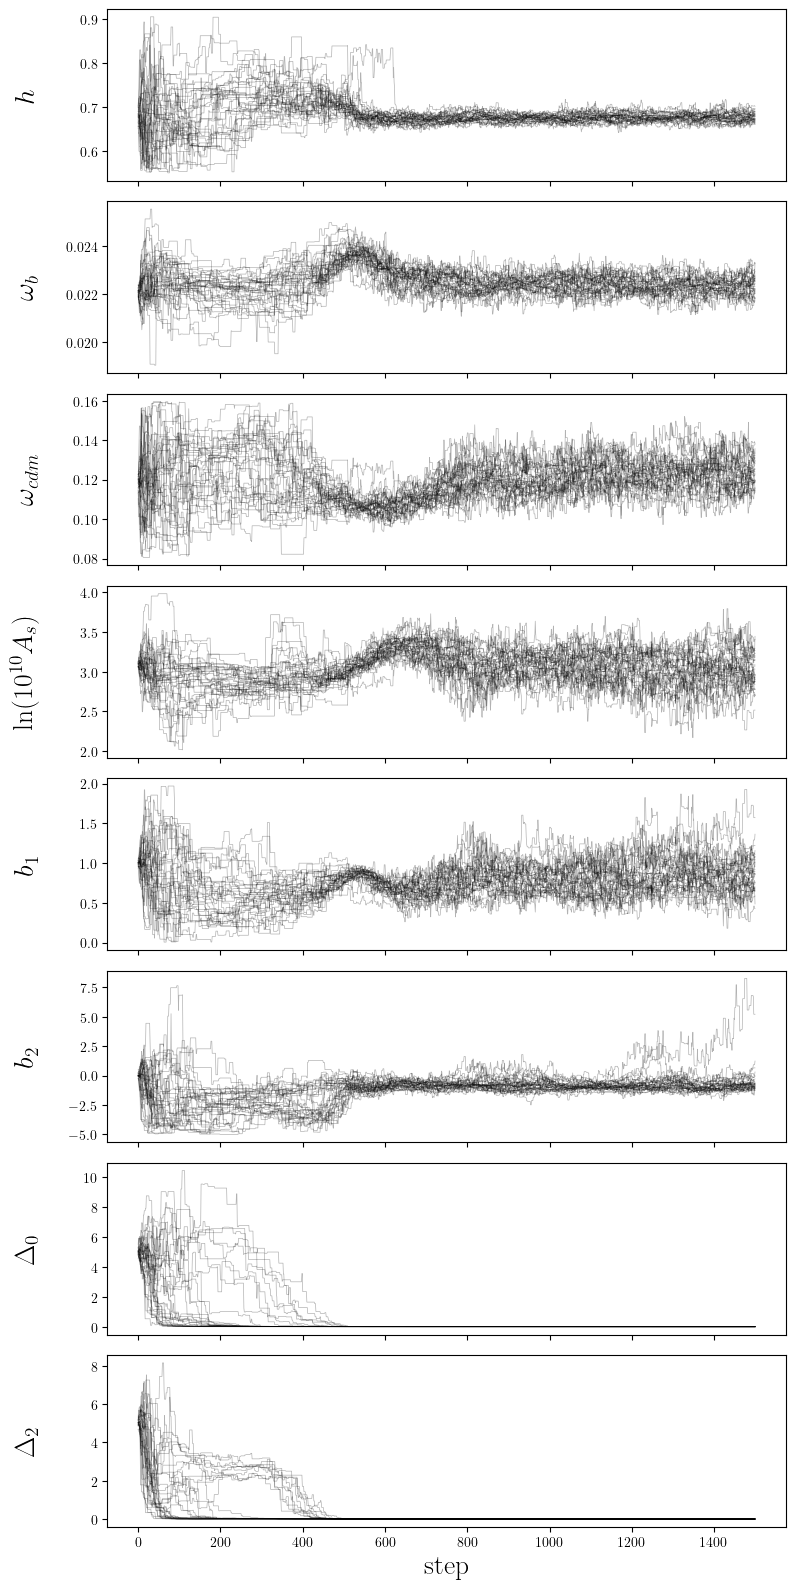

In [38]:
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

LABELS = [r'$h$', r'$\omega_b$', r'$\omega_{cdm}$', r'$\ln(10^{10}A_s)$',
          r'$b_1$', r'$b_2$', r'$\Delta_0$', r'$\Delta_2$']

chain = sampler.get_chain()   # (nsteps, nwalkers, ndim)

fig, axes = plt.subplots(NDIM, figsize=(8, 2 * NDIM), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(chain[:, :, i], alpha=0.3, lw=0.5, color='k')
    ax.set_ylabel(LABELS[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel('step')
fig.tight_layout()

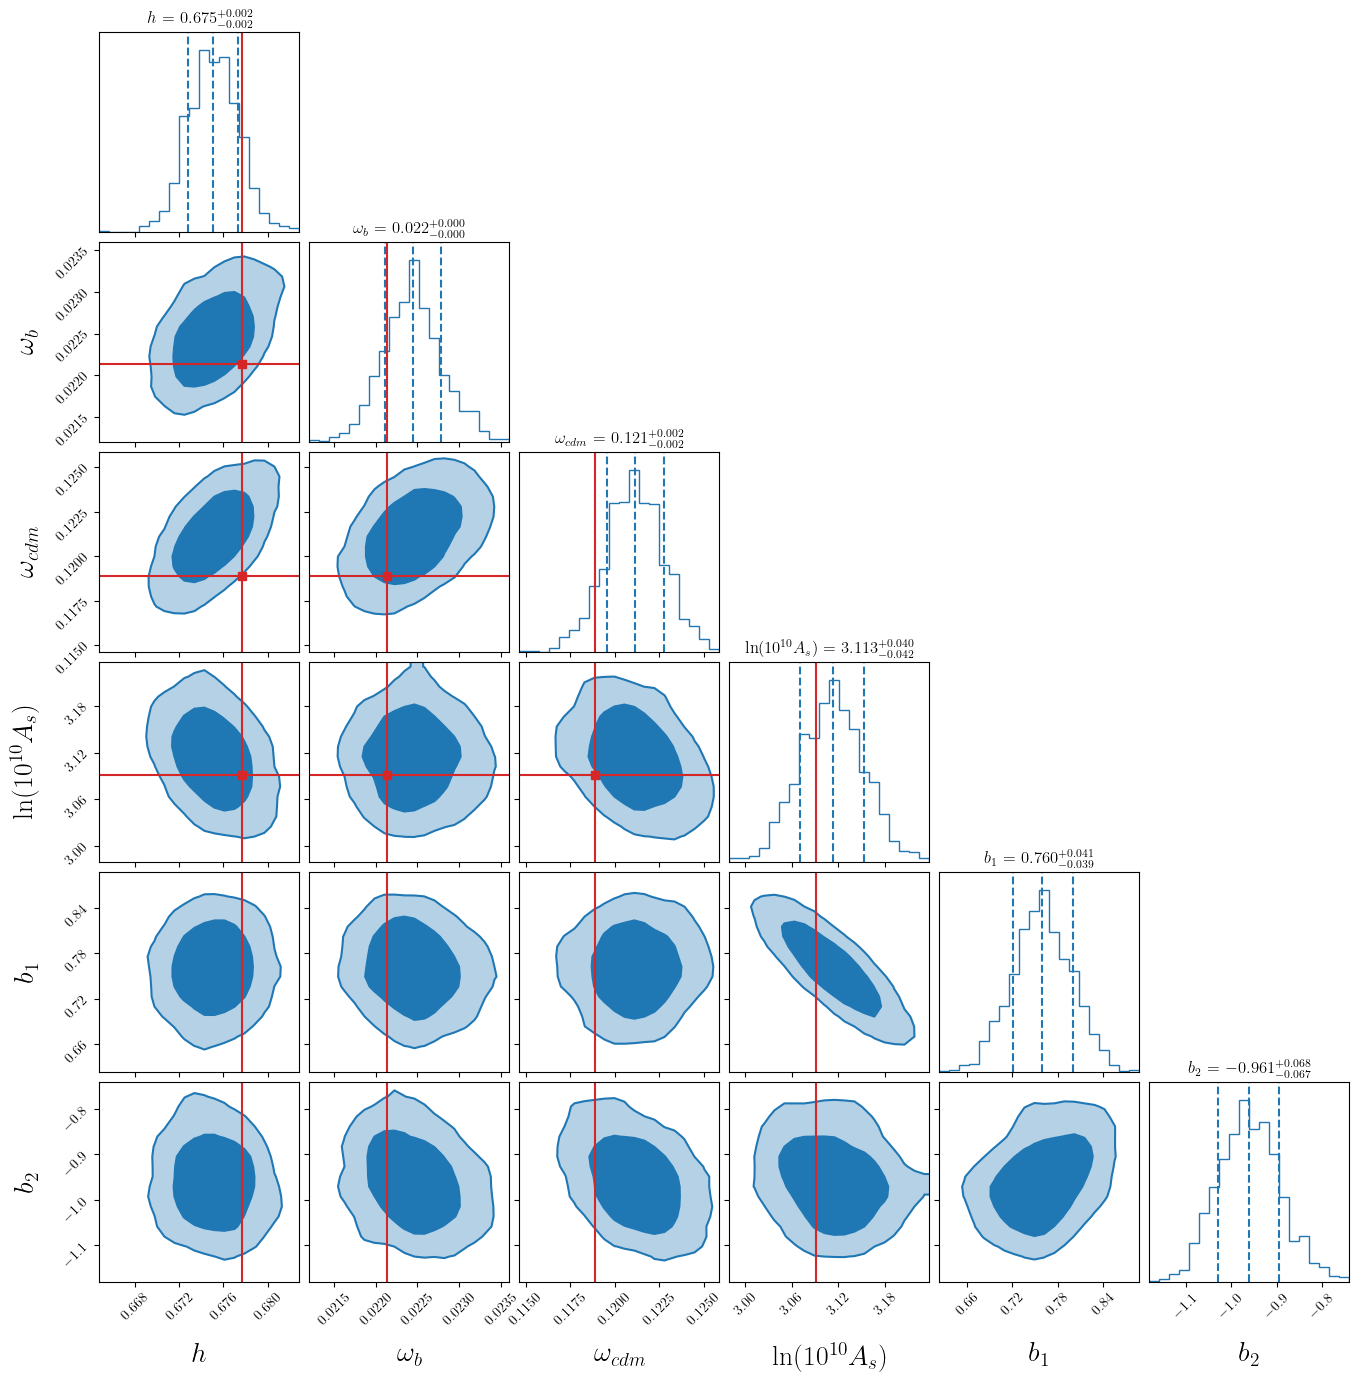

In [22]:
import corner

BURNIN = 800    # TODO: confirm against trace plots -- discard until walkers look stationary
THIN = 15         # TODO: confirm against autocorrelation time

flat = sampler.get_chain(discard=BURNIN, thin=THIN, flat=True)

LABELS_CORNER = LABELS[:6]   # drop log10(Delta_0), log10(Delta_2)
flat_corner = flat[:, :6]

h_fid, ombh2_fid, omch2_fid, As_fid = COSMO_FID
lnAs_fid = np.log(1e10 * As_fid)
TRUTHS = [h_fid, ombh2_fid, omch2_fid, lnAs_fid, None, None]   # no fiducial for b1, b2

fig = corner.corner(
    flat_corner, labels=LABELS_CORNER, show_titles=True, title_fmt='.3f',
    quantiles=[0.16, 0.5, 0.84],
    levels=[0.68, 0.95],
    smooth=1.0,
    color='C0',
    plot_datapoints=False,
    fill_contours=True,
    truths=TRUTHS,
    truth_color='C3',
)

MAP parameters:
  $h$: 0.67334
  $\omega_b$: 0.02223
  $\omega_{cdm}$: 0.12023
  $\ln(10^{10}A_s)$: 3.07007
  $b_1$: 0.81960
  $b_2$: -0.90655
  $\Delta_0$: 0.00001
  $\Delta_2$: 0.00010
log-likelihood at MAP: 322.63


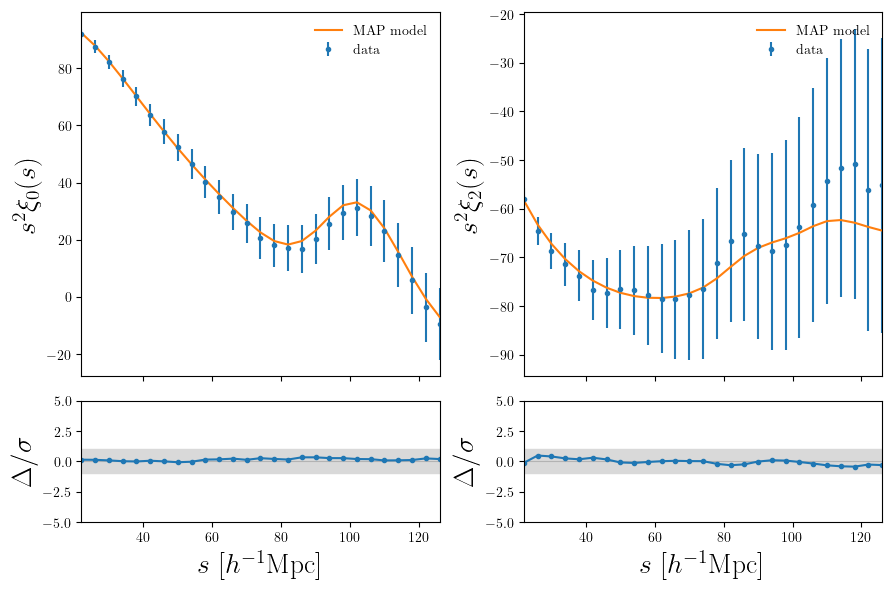

In [39]:
log_prob = sampler.get_log_prob(discard=BURNIN, thin=THIN, flat=True)
map_idx = np.argmax(log_prob)
theta_map = flat[map_idx]

model_map = model_multipoles(theta_map)   # [xi0(s_data), xi2(s_data)]
xi0_data, xi2_data = np.split(DATA_VEC, 2)
xi0_map, xi2_map = np.split(model_map, 2)
err0 = np.sqrt(np.diag(COV))[:N_PER_ELL]
err2 = np.sqrt(np.diag(COV))[N_PER_ELL:]

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex='col',
                          gridspec_kw={'height_ratios': [3, 1]})

for ax_top, ax_bot, xi_d, xi_m, err, ell in zip(
        axes[0], axes[1], (xi0_data, xi2_data), (xi0_map, xi2_map), (err0, err2), ELLS_FIT):
    ax_top.errorbar(S_DATA, S_DATA**2 * xi_d, S_DATA**2 * err, fmt='o', ms=3, label='data')
    ax_top.plot(S_DATA, S_DATA**2 * xi_m, '-', label='MAP model')
    ax_top.set_ylabel(fr'$s^2\xi_{ell}(s)$')
    ax_top.legend(frameon=False)
    ax_top.margins(x=0)

    ax_bot.axhspan(-1, 1, color='0.85', zorder=0)
    ax_bot.axhline(0, color='0.7', lw=0.8)
    ax_bot.plot(S_DATA, (xi_m - xi_d) / err, 'o-', ms=3)
    ax_bot.set_ylim(-5, 5)
    ax_bot.set_ylabel(r'$\Delta/\sigma$')
    ax_bot.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
    ax_bot.margins(x=0)

fig.tight_layout()

print('MAP parameters:')
for name, val in zip(LABELS, theta_map):
    print(f'  {name}: {val:.5f}')
print(f'log-likelihood at MAP: {log_likelihood(theta_map):.2f}')


Removed no burn in


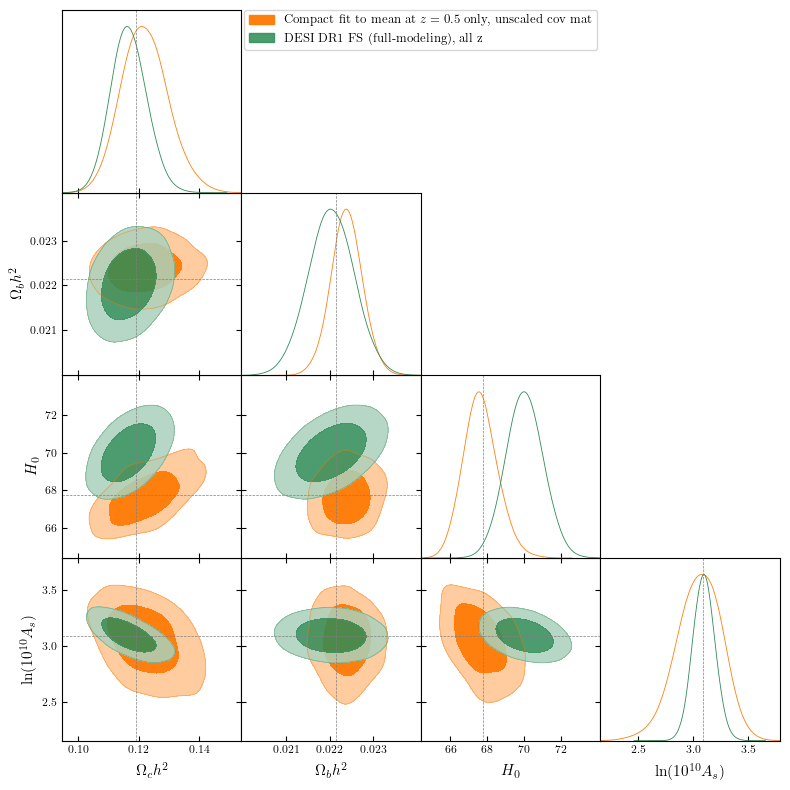

In [40]:
import numpy as np
from getdist import MCSamples, loadMCSamples, plots

# --- your chain ---
chain = sampler.get_chain(discard=800, flat=True)  # (nsteps-burn)*nwalkers x NDIM

# column order from theta0: h, ombh2, omch2, logA, b1, b2, alpha0, alpha2
chain = chain.copy()
chain[:, 0] *= 100.0  # h -> H0

h_fid, ombh2_fid, omch2_fid, lnAs_fid, _, _ = TRUTHS

truths = {
    "H0": 100.0 * h_fid,   # convert fiducial h -> H0 to match the plotted parameter
    "ombh2": ombh2_fid,
    "omch2": omch2_fid,
    "logA": lnAs_fid,
}

names  = ["H0", "ombh2", "omch2", "logA", "b1", "b2", "alpha0", "alpha2"]
labels = ["H_0", "\\Omega_b h^2", "\\Omega_c h^2", "\\ln(10^{10}A_s)",
          "b_1", "b_2", "\\alpha_0", "\\alpha_2"]

my_samples = MCSamples(samples=chain, names=names, labels=labels, label=r"Compact fit to mean at $z=0.5$ only", settings={'smooth_scale_1D': 0.5, 'smooth_scale_2D': 0.5},)

# factor = 5.0  # sqrt(25) -- undoes the cov/25 rescaling
# mean = chain.mean(axis=0)
# chain_widened = mean + (chain - mean) * factor

# my_samples_widened = MCSamples(
#     samples=chain_widened, names=names, labels=labels,
#     label=r"Compact fit to mean at $z=0.5$ only (rescaled to $N=1$ precision)",
#     settings={'smooth_scale_1D': 0.5, 'smooth_scale_2D': 0.5},
# )

# --- DR1 chain ---
base = "/spiffball/cosweeney/DESI/DR1/full-shape-cosmo-params/v1.0/cobaya/base/desi-reptvelocileptors-fs-all_schoneberg2024-bbn_planck2018-ns10/"
desi_samples = loadMCSamples(f"{base}chain")

# --- plot, excluding n_s ---
g = plots.get_subplot_plotter()
g.triangle_plot([my_samples, desi_samples], params=["omch2", "ombh2", "H0", "logA"],
                 filled=True, 
                 legend_labels=[r"Compact fit to mean at $z=0.5$ only, unscaled cov mat", "DESI DR1 FS (full-modeling), all z"], 
                 markers=truths, 
                 contour_colors=["tab:orange", "seagreen"])

In [41]:
my_samples.saveAsText("/spiffball/cosweeney/data/chains/mocks/mean_unscaled_mock_test_z0p5_fix_ns")

In [34]:
my_samples.saveAsText("/spiffball/cosweeney/data/chains/mocks/mean_mock_test_z0p5_fix_ns")

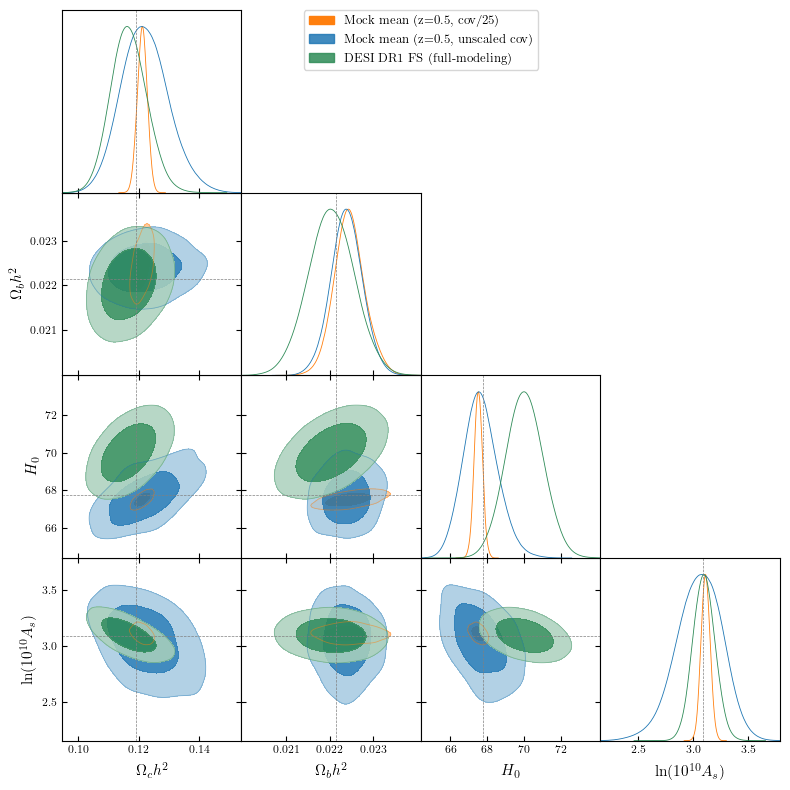

In [46]:
from getdist import loadMCSamples, plots

chain1 = loadMCSamples("/spiffball/cosweeney/data/chains/mocks/mean_mock_test_z0p5_fix_ns", settings={'smooth_scale_1D': 0.5, 'smooth_scale_2D': 0.5})
chain2 = loadMCSamples("/spiffball/cosweeney/data/chains/mocks/mean_unscaled_mock_test_z0p5_fix_ns", settings={'smooth_scale_1D': 0.5, 'smooth_scale_2D': 0.5},)  

base = "/spiffball/cosweeney/DESI/DR1/full-shape-cosmo-params/v1.0/cobaya/base/desi-reptvelocileptors-fs-all_schoneberg2024-bbn_planck2018-ns10/"
desi_samples = loadMCSamples(f"{base}chain")

g = plots.get_subplot_plotter()
g.triangle_plot([chain1, chain2, desi_samples], params=["omch2", "ombh2", "H0", "logA"],
                 filled=True,
                 legend_labels=["Mock mean (z=0.5, cov/25)", "Mock mean (z=0.5, unscaled cov)", "DESI DR1 FS (full-modeling)"],
                 contour_colors=["tab:orange", "tab:blue", "seagreen"], 
                 markers=truths) 

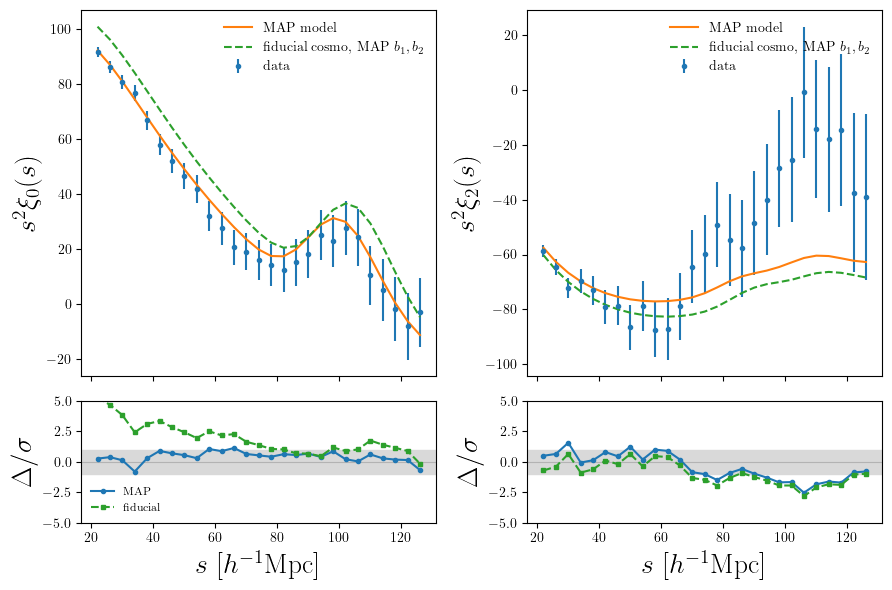

In [30]:
b1_fid, b2_fid = 0.869, -1.059
theta_fid = np.array([h_fid, ombh2_fid, omch2_fid, lnAs_fid, b1_fid, b2_fid, 0., 0.])
# last two entries (log10 Delta_0, log10 Delta_2) are unused in model_multipoles, placeholders only

model_fid = model_multipoles(theta_fid)
xi0_fid, xi2_fid = np.split(model_fid, 2)

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex='col',
                          gridspec_kw={'height_ratios': [3, 1]})

for ax_top, ax_bot, xi_d, xi_m, xi_f, err, ell in zip(
        axes[0], axes[1], (xi0_data, xi2_data), (xi0_map, xi2_map),
        (xi0_fid, xi2_fid), (err0, err2), ELLS_FIT):
    ax_top.errorbar(S_DATA, S_DATA**2 * xi_d, S_DATA**2 * err, fmt='o', ms=3, label='data')
    ax_top.plot(S_DATA, S_DATA**2 * xi_m, '-', label='MAP model')
    ax_top.plot(S_DATA, S_DATA**2 * xi_f, '--', color='C2', label='fiducial cosmo, MAP $b_1,b_2$')
    ax_top.set_ylabel(fr'$s^2\xi_{ell}(s)$')
    ax_top.legend(frameon=False)

    ax_bot.axhspan(-1, 1, color='0.85', zorder=0)
    ax_bot.axhline(0, color='0.7', lw=0.8)
    ax_bot.plot(S_DATA, (xi_m - xi_d) / err, 'o-', ms=3, label='MAP')
    ax_bot.plot(S_DATA, (xi_f - xi_d) / err, 's--', ms=3, color='C2', label='fiducial')
    ax_bot.set_ylim(-5, 5)
    ax_bot.set_ylabel(r'$\Delta/\sigma$')
    ax_bot.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')

axes[1, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()

In [17]:
r = np.arange(16.0, 169.0 + 4.0, 1.0)      # h^-1 Mpc; 16, 17, ..., 168 (38 bins)
r.max()

np.float64(172.0)

In [ ]:
poles_mock.shape

(24, 3, 45)

/tmp/ipykernel_1997218/2207783827.py:27: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True)


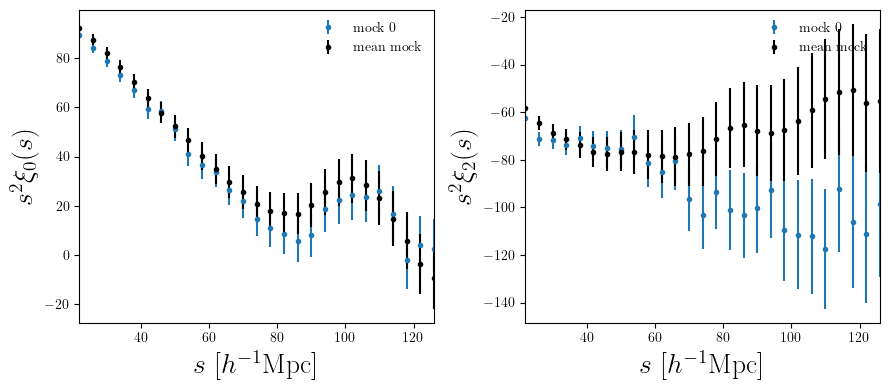

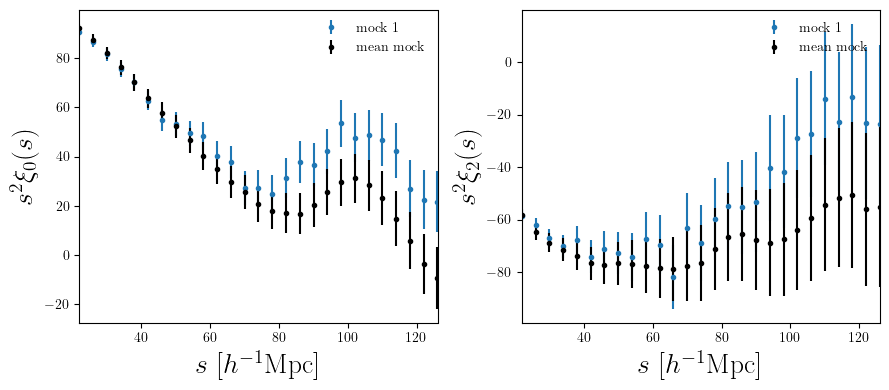

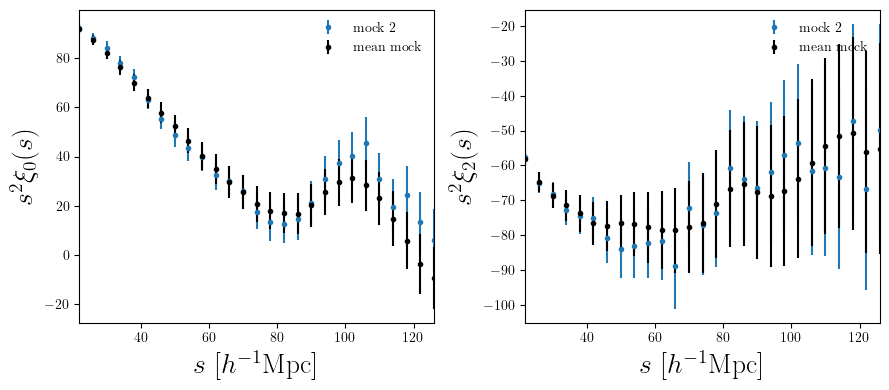

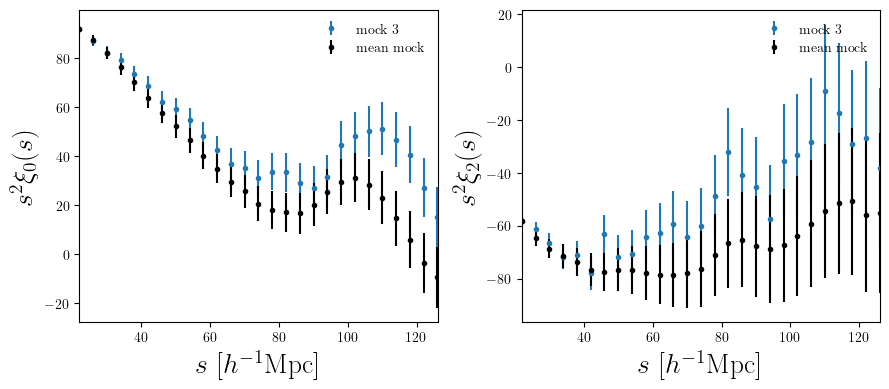

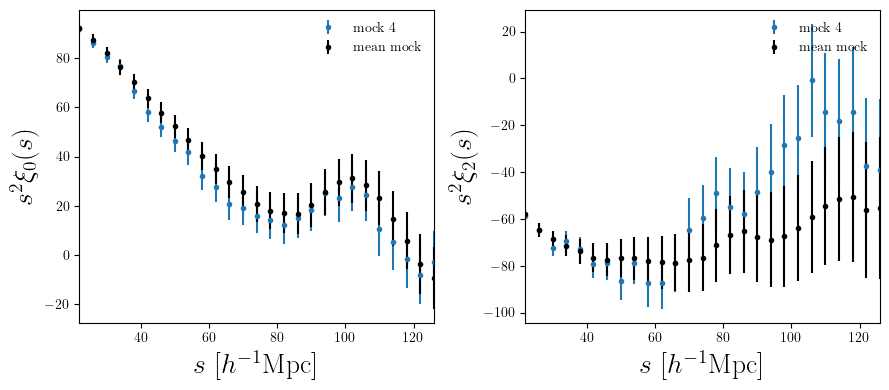

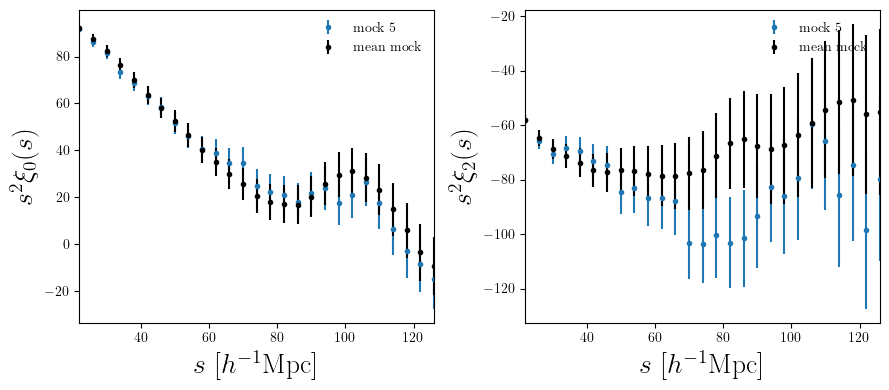

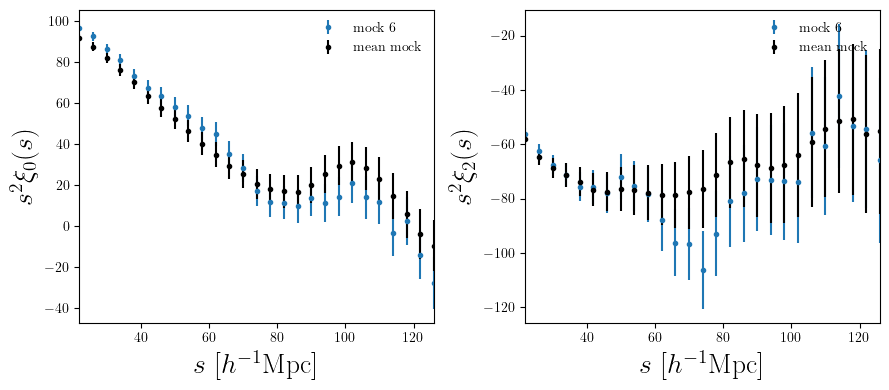

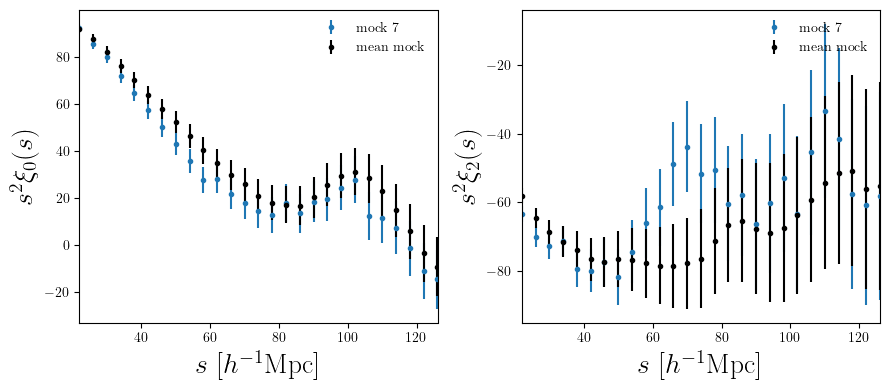

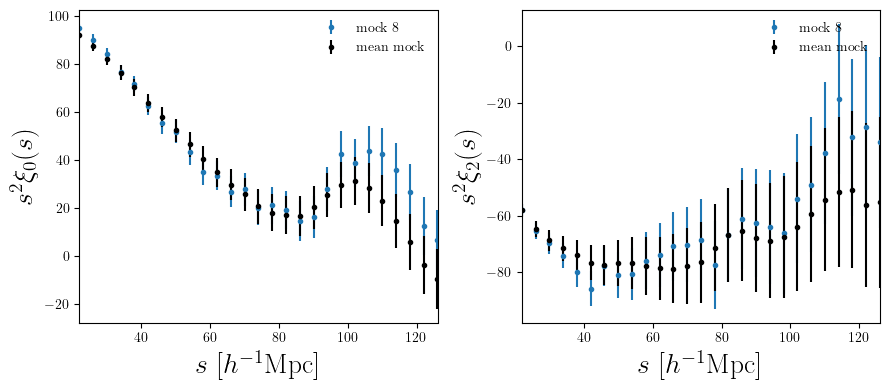

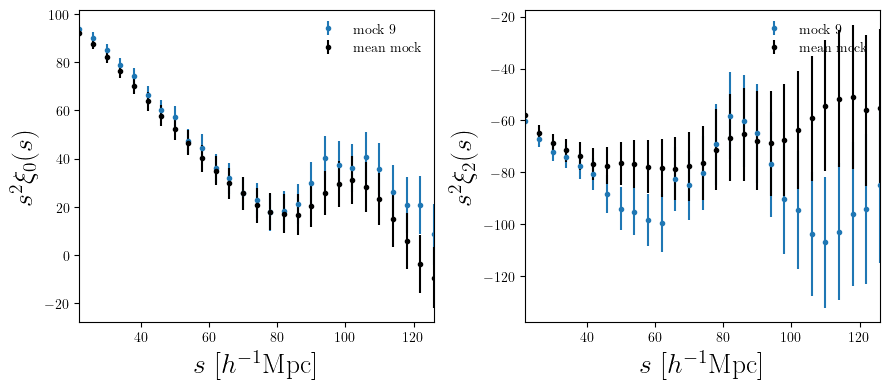

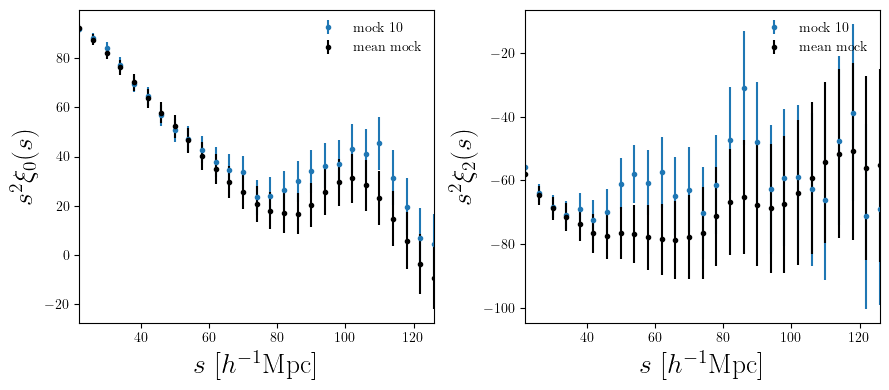

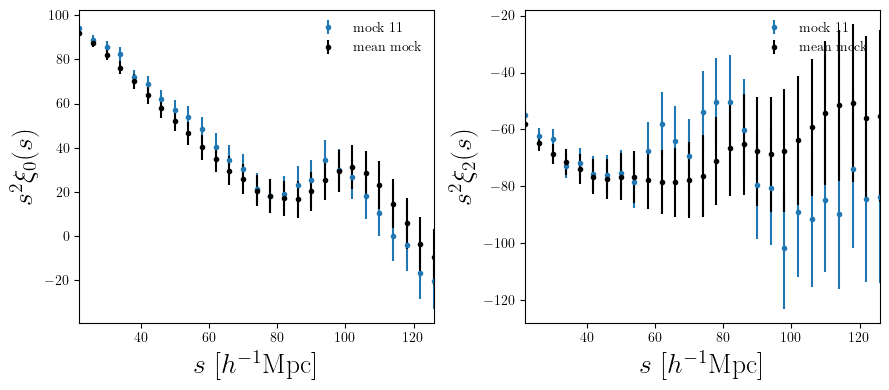

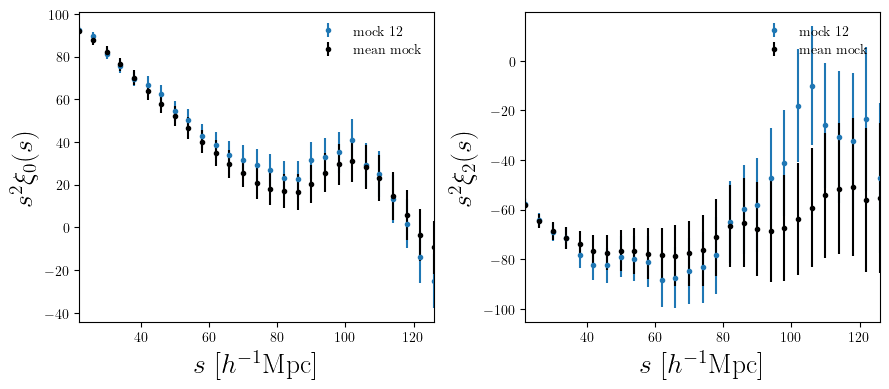

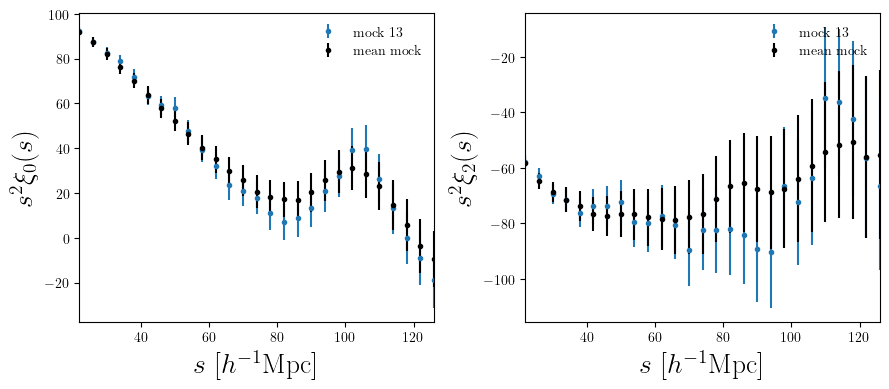

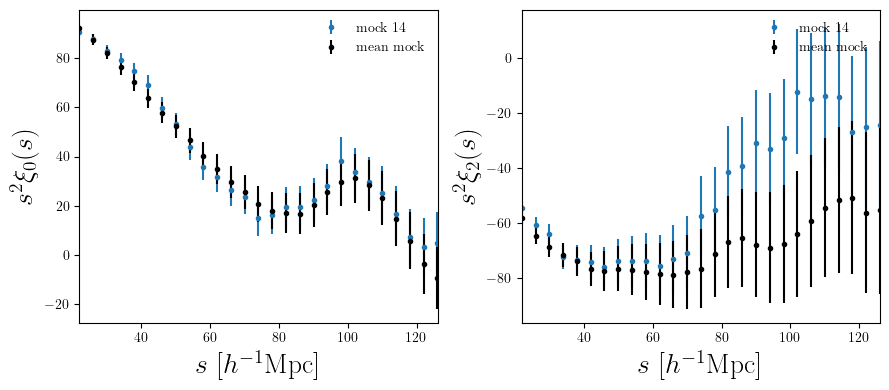

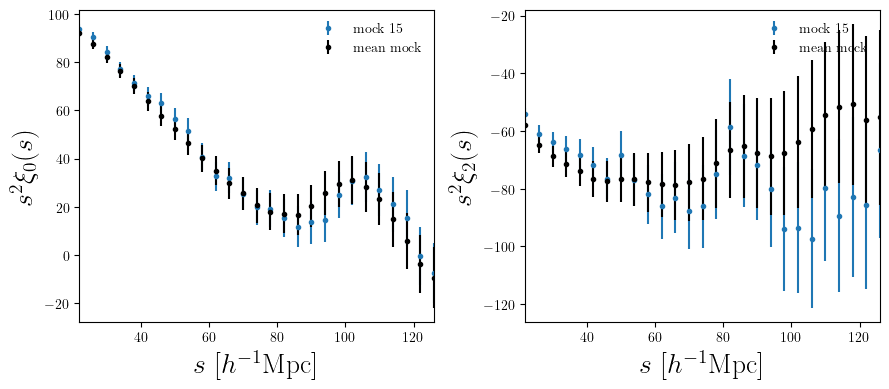

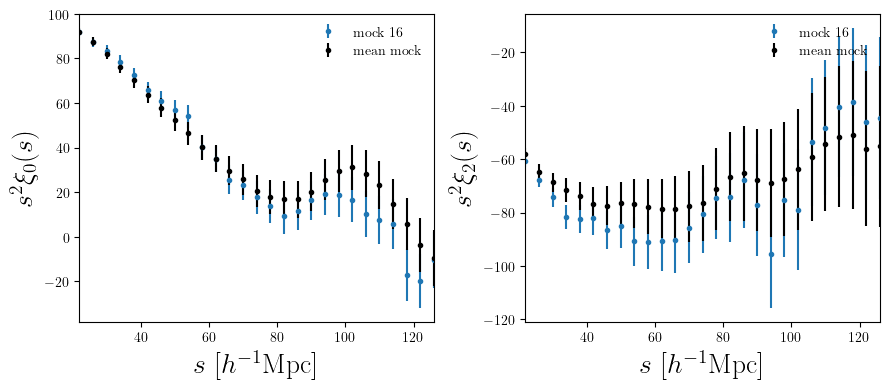

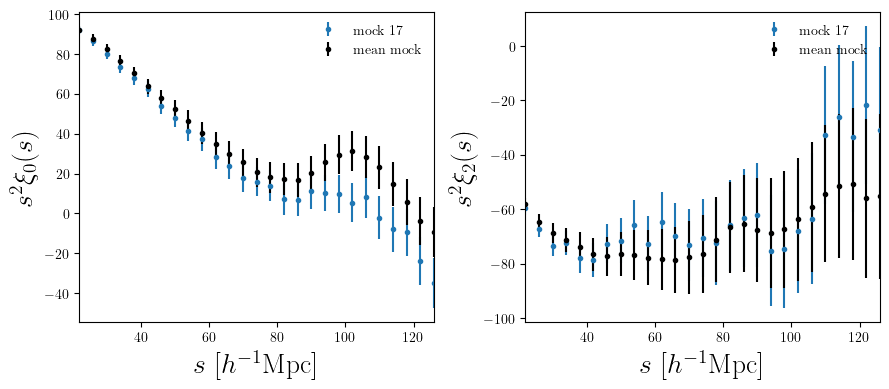

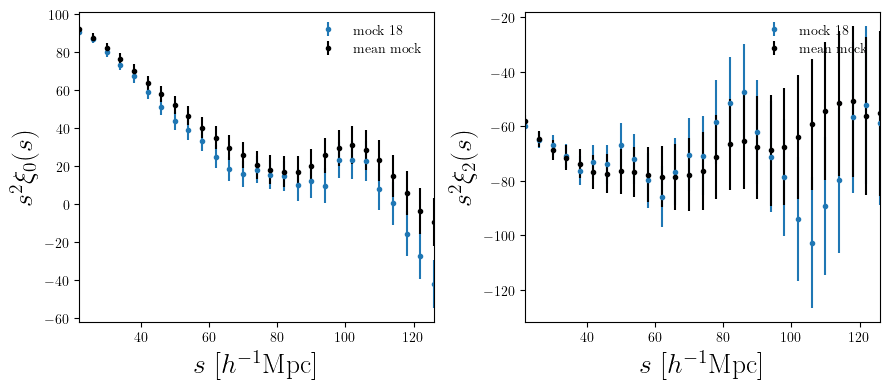

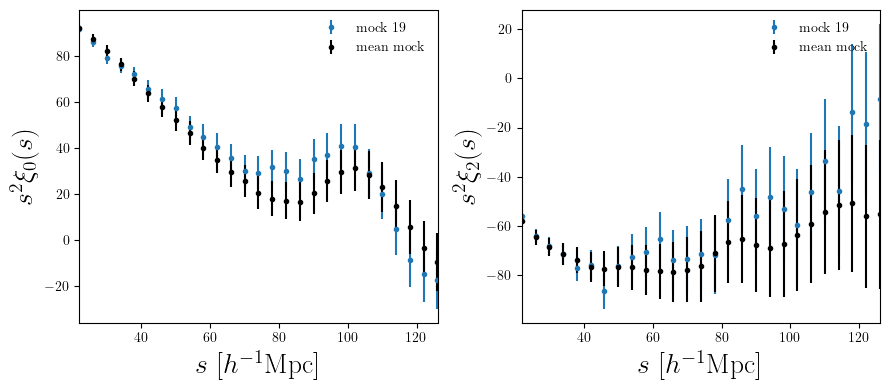

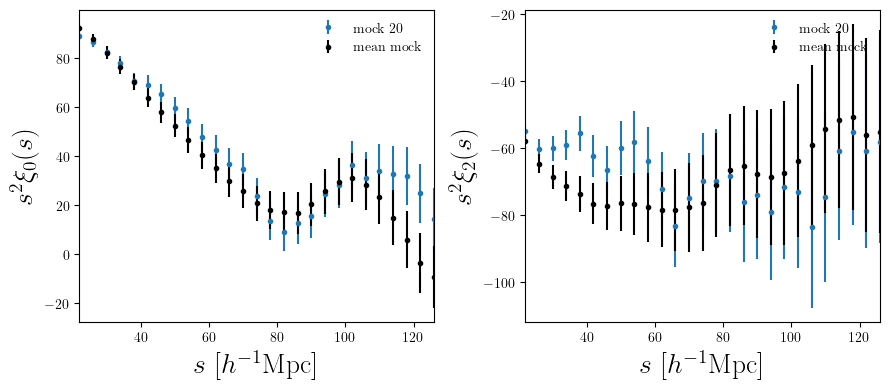

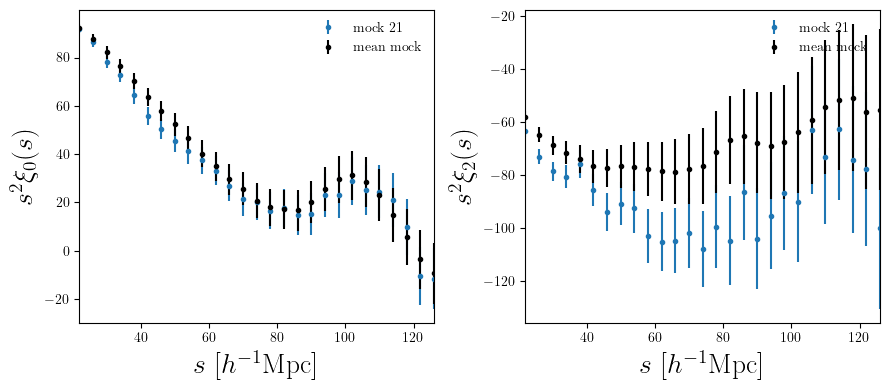

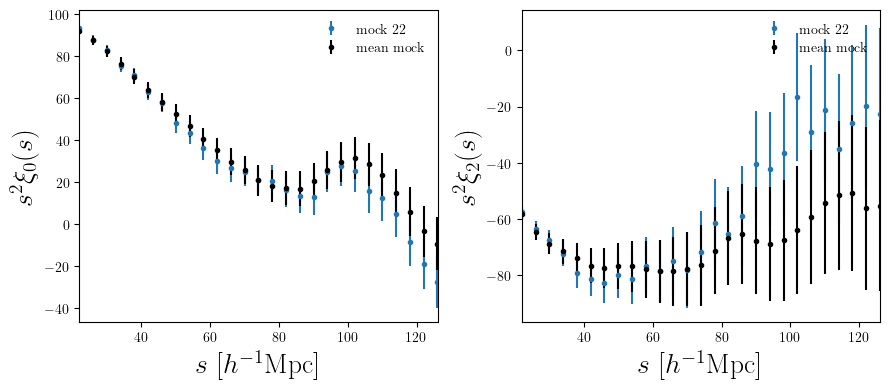

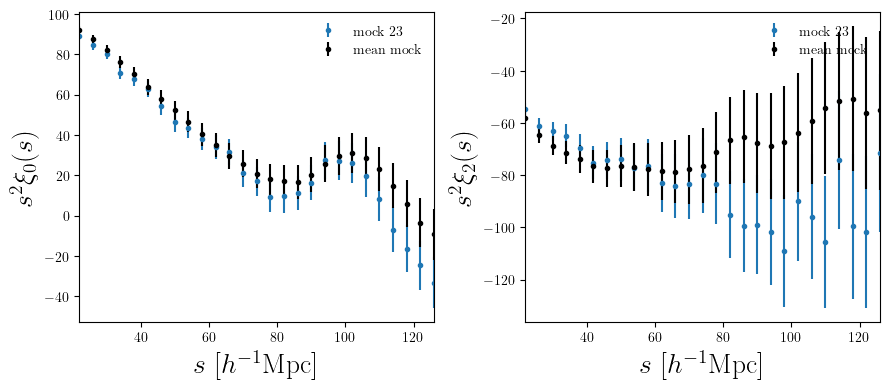

In [39]:
MOCK_IDX = 4   # TODO: pick which mock to show

poles_path='/spiffball/cosweeney/mocks/AbacusSummit/dark/LRG_z0.4-0.6_poles.npz'   # TODO: path to the non-rebinned, srange=(20,200) export for LRG z0.4-0.6
cov_path="/spiffball/cosweeney/mocks/AbacusSummit/covariances/dark/xi024_LRG_GCcomb_0.4_0.6_default_FKP_lin4_s20-200_cov_RascalC_rescaled_mocks.txt"

xi0_data, xi2_data = np.split(DATA_VEC, 2)
err0 = np.sqrt(np.diag(COV))[:N_PER_ELL]
err2 = np.sqrt(np.diag(COV))[N_PER_ELL:]

poles_mock_mean = np.mean(rebin_mean(poles_fine, REBIN, axis=-1), axis=0)

d = np.load(poles_path)   # non-rebinned export, same file used in load_data
s_fine, poles_fine = d['s'], d['poles']
s_mock = rebin_mean(s_fine, REBIN)

for idx in range(poles_fine.shape[0]):
    poles_mock = rebin_mean(poles_fine, REBIN, axis=-1)[idx]   # (3, 45)

    mask = s_mock <= SMAX_FIT
    ell_all = (0, 2, 4)
    xi0_mock = poles_mock[ell_all.index(0)][mask]
    xi2_mock = poles_mock[ell_all.index(2)][mask]

    xi0_mean = poles_mock_mean[ell_all.index(0)][mask]
    xi2_mean = poles_mock_mean[ell_all.index(2)][mask]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True)
    for ax, xi_mock, xi_mean, err, ell in zip(axes, (xi0_mock, xi2_mock), (xi0_mean, xi2_mean), (err0, err2), ELLS_FIT):
        ax.errorbar(S_DATA, S_DATA**2 * xi_mock, S_DATA**2 * err, fmt='o', ms=3,
                    label=f'mock {idx}')
        ax.errorbar(S_DATA, S_DATA**2 * xi_mean, S_DATA**2 * err, fmt='o', ms=3,
                    label=f'mean mock', c='k')
        ax.set_ylabel(fr'$s^2\xi_{ell}(s)$')
        ax.set_xlabel(r'$s\ [h^{-1}\mathrm{Mpc}]$')
        ax.legend(frameon=False)
        ax.margins(x=0)
    fig.tight_layout()

In [43]:
d = np.load(poles_path)   # non-rebinned export
s_fine, poles_fine = d['s'], d['poles']

s = rebin_mean(s_fine, REBIN)
poles = rebin_mean(poles_fine, REBIN, axis=-1)   # (nmock, 3, 45)

mask = s <= SMAX_FIT
ell_all = (0, 2, 4)

mean_vec = np.concatenate([poles.mean(axis=0)[ell_all.index(ell)][mask] for ell in ELLS_FIT])

cov_inv = np.linalg.inv(COV)   # single-mock covariance, appropriate metric per-mock

dists = np.empty(poles.shape[0])
for i in range(poles.shape[0]):
    vec = np.concatenate([poles[i][ell_all.index(ell)][mask] for ell in ELLS_FIT])
    resid = vec - mean_vec
    dists[i] = resid @ cov_inv @ resid   # chi2 distance to the mean

closest_idx = np.argmin(dists)
print(f'closest mock: {closest_idx}  (chi2 = {dists[closest_idx]:.2f})')
print('all distances:', np.round(dists, 2))

closest mock: 22  (chi2 = 40.39)
all distances: [69.5  64.52 42.43 64.53 58.92 52.59 53.06 59.78 47.14 49.24 49.48 67.99
 45.39 50.65 41.31 47.94 56.21 45.42 61.29 59.39 64.59 68.72 40.39 67.13]
